In [15]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np

from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.distributions import MultivariateNormal
from sbi.analysis import pairplot

In [50]:
x_dim = 100
theta_dim = 10

prior = MultivariateNormal(jnp.zeros(theta_dim), jnp.eye(theta_dim))
A = jrandom.normal(jrandom.PRNGKey(0), (x_dim,theta_dim))
likelihood_cov = jnp.eye(x_dim)*0.1
likelihood_scale = jnp.linalg.cholesky(likelihood_cov)

def simulator(key, theta):
    x_o = A @ theta
    eps = likelihood_scale@jrandom.normal(key, (x_dim,))
    return x_o + eps


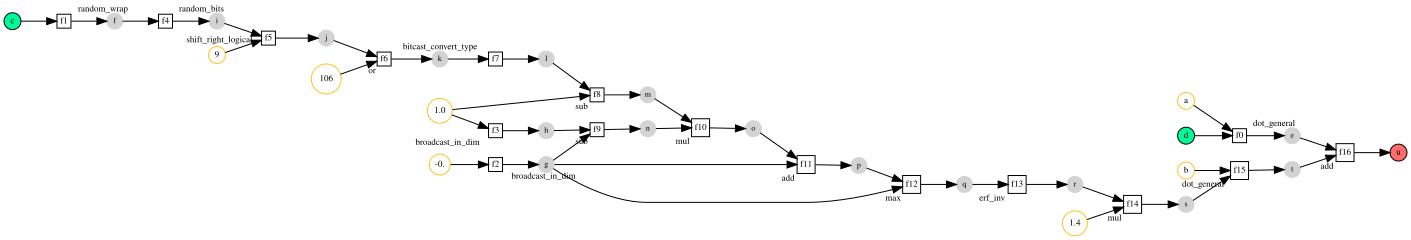

In [51]:
jaxpr = jax.make_jaxpr(simulator)(jrandom.PRNGKey(0), jnp.zeros(theta_dim))
graph = JaxprGraph(jaxpr.jaxpr)
graph

In [52]:
def conjugate_posterior(prior_mean, prior_cov, observations, obs_cov, A):
    # Compute posterior parameters
    precision_prior = jnp.linalg.inv(prior_cov)
    precision_obs = jnp.linalg.inv(obs_cov)
    precision_post = precision_prior + A.T @ precision_obs @ A
    covariance_post = jnp.linalg.inv(precision_post)
    mean_diff = observations - A @ prior_mean
    mean_post = prior_mean + covariance_post @ A.T @ precision_obs @ mean_diff

    return mean_post, covariance_post


In [53]:
theta_o = jrandom.normal(jrandom.PRNGKey(42), (theta_dim,))
x_o = simulator(jrandom.PRNGKey(43), theta_o)
x_o

Array([ 0.204, -1.573,  1.528,  1.429,  5.893, -2.395,  1.687, -0.332,
        1.159, -0.495, -0.433,  0.848, -3.009, -1.461, -2.819,  1.353,
        2.943, -0.46 ,  0.417, -0.796, -4.913,  0.604, -0.941,  2.567,
       -1.9  ,  0.305, -1.685, -0.287, -2.159,  2.015,  0.025, -0.472,
       -0.017, -2.082, -4.749, -0.457, -0.501,  1.326, -1.21 , -2.989,
        0.064,  0.946,  2.598, -1.083,  1.468, -0.024,  0.83 , -1.93 ,
        3.364, -1.485,  1.259, -0.326, -2.021, -0.421, -0.258, -3.165,
        2.02 ,  0.882, -0.664, -0.578, -2.968,  3.614, -1.852, -1.693,
        2.932, -0.317, -2.695,  2.711, -1.083,  1.114, -3.151, -2.546,
       -1.983, -0.828, -2.75 ,  0.21 ,  1.216,  3.277, -0.795,  0.864,
        1.819,  0.589, -1.115,  0.464, -2.188,  2.09 ,  2.21 ,  0.099,
        2.796, -0.357, -0.501, -0.34 , -2.702, -4.584, -0.954, -2.677,
       -1.608,  0.44 ,  2.546, -3.698], dtype=float32)

In [54]:
post_mean, post_cov = conjugate_posterior(prior.mean, prior.covariance_matrix, x_o, likelihood_cov, A)
posterior = MultivariateNormal(post_mean, post_cov)

In [55]:
def inverse_matrix_vector_multiplication(A):
    eps = jnp.finfo(A.dtype).eps
    m,n = A.shape
    d = min(m,n)
    # SVD
    U, s, V_T = jnp.linalg.svd(A)
    # Filter out very small singular values
    s_inv = jnp.where(s > eps, 1/s, 0)
    is_zero = jnp.concatenate([s < eps, jnp.ones(n - d, dtype=bool)])



    # Orhtogonal basis of the null space
    basis = V_T[is_zero,:]
    # Pseudo inverse
    pseudo_inverse = V_T.T[:,:d] @ (jnp.diag(s_inv) @ U.T[:d,:])


    # Produces an independent sample from the solution space
    def sample_solution(key, b):
        x_star = pseudo_inverse @ b
        noise = basis.T @ jrandom.normal(key, (basis.shape[0],))
        return x_star + noise

    return sample_solution

In [56]:
sampling_fn = inverse_matrix_vector_multiplication(A)

def inverse_simulator(key, x):
    key1, key2 = jrandom.split(key, 2)
    noise = likelihood_scale@jrandom.normal(key1, (x_dim,))
    x_o = x - noise
    theta = sampling_fn(key2, x_o)
    return theta

batched_inverse_simulator = jax.vmap(inverse_simulator, in_axes=(0, None), out_axes=0)

In [57]:
thetas = batched_inverse_simulator(jrandom.split(jrandom.PRNGKey(0), 10000), x_o)
thetas_true = posterior.sample(jrandom.PRNGKey(0), (10000,))

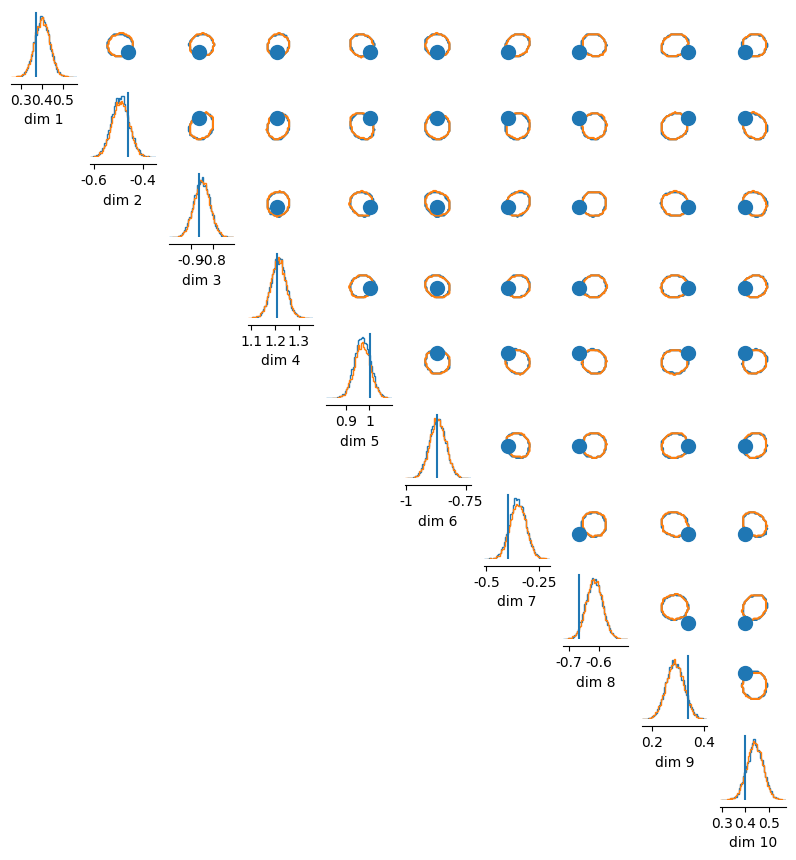

In [58]:
_ = pairplot([np.array(thetas), np.array(thetas_true)], upper="contour", points=np.array(theta_o))